In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import json

mpl.rcParams.update({
    'axes.titlesize'   : 0,        # no title
    'axes.labelsize'   : 14,       # x and y axis labels
    'xtick.labelsize'  : 12,       # x tick labels
    'ytick.labelsize'  : 12,       # y tick labels
    'legend.fontsize'  : 12,
    'font.size'        : 12,      
})

In [2]:
df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")

/tmp/ipykernel_119233/2256054893.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")


In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.auto import tqdm

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({"sent_pos":0.0, "sent_neg":0.0, "sent_neu":0.0, "sent_compound":0.0})
    s = analyzer.polarity_scores(text)
    return pd.Series({"sent_pos":s["pos"], "sent_neg":s["neg"], "sent_neu":s["neu"], "sent_compound":s["compound"]})

tqdm.pandas()
df = df.copy()
df[["sent_pos","sent_neg","sent_neu","sent_compound"]] = df["text"].progress_apply(vader_sentiment)


  0%|          | 0/71808 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df["sent_intensity"] = (
    df["sent_pos"] + df["sent_neg"]
).astype(np.float32)

# Density-style (not divided by words; just a scale change)
df["neg_per_100w"] = df["sent_neg"] * 100
df["pos_per_100w"] = df["sent_pos"] * 100

df[["sent_pos","sent_neg","sent_intensity","neg_per_100w","pos_per_100w"]].describe()


In [ ]:
df["election_year"] = df["election_date"].astype(str).str[:4].astype("Int64")



In [ ]:
set(df["election_year"])

In [ ]:
df["person"] = (
    df["person"].astype(str)
    + "_"
    + df["election_year"].astype(str)
)


In [ ]:
df_pop = df[df["Populism"] == 1]
df_non = df[df["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

In [ ]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())


# Positive

In [ ]:
import statsmodels.api as sm

y = df_balanced["sent_pos"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


In [ ]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["sent_pos"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)


In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "sent_pos ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())


# Negative

In [ ]:
import statsmodels.api as sm

y = df_balanced["sent_neg"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())

In [ ]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["sent_neg"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "sent_neg ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())

# Intensity

In [ ]:
import statsmodels.api as sm

y = df_balanced["sent_intensity"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())

In [ ]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["sent_intensity"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "sent_intensity ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())

In [ ]:
df.to_csv("prof_llm_sentiment.csv", encoding="utf-8", index=False)

In [3]:
dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_sentiment_with_roberta.csv", encoding="utf-8")

/tmp/ipykernel_119233/1067500030.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_sentiment_with_roberta.csv", encoding="utf-8")


In [4]:
df_pop = dfllm[dfllm["Populism"] == 1]
df_non = dfllm[dfllm["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [5]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())

1    1861
0    1861
Name: Populism, dtype: int64


# Positive

In [6]:
import statsmodels.api as sm

y = df_balanced["rob_pos"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                rob_pos   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     208.6
Date:                Mon, 04 May 2026   Prob (F-statistic):           4.71e-46
Time:                        11:05:13   Log-Likelihood:                -2416.9
No. Observations:                3722   AIC:                             4838.
Df Residuals:                    3720   BIC:                             4850.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7368      0.010     73.396      0.0

In [7]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["rob_pos"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(-0.2159526147918786, 0.010469939741750327)

In [8]:
import statsmodels.api as sm

y = df_balanced["rob_pos"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                rob_pos   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     123.5
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.15e-52
Time:                        11:05:13   Log-Likelihood:                -2405.8
No. Observations:                3722   AIC:                             4818.
Df Residuals:                    3719   BIC:                             4836.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.7029      0.013     

In [9]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "rob_pos ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:                rob_pos   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     5.973
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0200
Time:                        11:05:14   Log-Likelihood:                -2289.0
No. Observations:                3722   AIC:                             4648.
Df Residuals:                    3687   BIC:                             4866.
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


# Negative

In [10]:
import statsmodels.api as sm

y = df_balanced["rob_neg"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                rob_neg   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     208.6
Date:                Mon, 04 May 2026   Prob (F-statistic):           4.71e-46
Time:                        11:05:14   Log-Likelihood:                -2416.9
No. Observations:                3722   AIC:                             4838.
Df Residuals:                    3720   BIC:                             4850.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2632      0.010     26.214      0.0

In [11]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["rob_neg"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(0.21595261499057872, 0.010469939817676419)

In [12]:
import statsmodels.api as sm

y = df_balanced["rob_neg"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                rob_neg   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     123.5
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.15e-52
Time:                        11:05:14   Log-Likelihood:                -2405.8
No. Observations:                3722   AIC:                             4818.
Df Residuals:                    3719   BIC:                             4836.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2971      0.013     

In [13]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "rob_neg ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:                rob_neg   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     5.973
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0200
Time:                        11:05:14   Log-Likelihood:                -2289.0
No. Observations:                3722   AIC:                             4648.
Df Residuals:                    3687   BIC:                             4866.
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


# Intensity

In [14]:
import statsmodels.api as sm

y = df_balanced["rob_intensity"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          rob_intensity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6327
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.426
Time:                        11:05:14   Log-Likelihood:                 58282.
No. Observations:                3722   AIC:                        -1.166e+05
Df Residuals:                    3720   BIC:                        -1.165e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0000   8.95e-10   1.12e+09      0.0

In [15]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["rob_intensity"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(5.932180775791197e-10, 8.625627060527553e-10)

In [16]:
import statsmodels.api as sm

y = df_balanced["rob_intensity"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          rob_intensity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3467
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.707
Time:                        11:05:15   Log-Likelihood:                 58282.
No. Observations:                3722   AIC:                        -1.166e+05
Df Residuals:                    3719   BIC:                        -1.165e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.0000   1.07e-09   9.

In [17]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "rob_intensity ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:          rob_intensity   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                 8.427e+13
Date:                Mon, 04 May 2026   Prob (F-statistic):          1.60e-221
Time:                        11:05:15   Log-Likelihood:                 58297.
No. Observations:                3722   AIC:                        -1.165e+05
Df Residuals:                    3687   BIC:                        -1.163e+05
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 30
  warnings.warn('covariance of constraints does not have full '


In [18]:
dfllm_tweet = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_sentiment_with_twitter_roberta.csv", encoding="utf-8")

/tmp/ipykernel_119233/2497171252.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dfllm_tweet = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_sentiment_with_twitter_roberta.csv", encoding="utf-8")


In [19]:
label_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

dfllm_tweet["sentiment_label"] = (
    dfllm_tweet["tw_label"]
    .map(label_map)
    .astype(np.int8)
)

In [20]:
df_pop = dfllm_tweet[dfllm_tweet["Populism"] == 1]
df_non = dfllm_tweet[dfllm_tweet["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [21]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())

1    1861
0    1861
Name: Populism, dtype: int64


In [22]:
y = df_balanced["sentiment_label"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_label   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     308.3
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.29e-66
Time:                        11:05:16   Log-Likelihood:                -4266.5
No. Observations:                3722   AIC:                             8537.
Df Residuals:                    3720   BIC:                             8550.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1333      0.018      7.384      0.0

In [23]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["sentiment_label"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(-0.44283181085437806, 0.01921788188455798)

In [24]:
import statsmodels.api as sm

y = df_balanced["sentiment_label"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_label   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     171.6
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.44e-72
Time:                        11:05:17   Log-Likelihood:                -4251.3
No. Observations:                3722   AIC:                             8509.
Df Residuals:                    3719   BIC:                             8527.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0678      0.022     

In [25]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "sentiment_label ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_label   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     2.010
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.166
Time:                        11:05:17   Log-Likelihood:                -4176.6
No. Observations:                3722   AIC:                             8423.
Df Residuals:                    3687   BIC:                             8641.
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


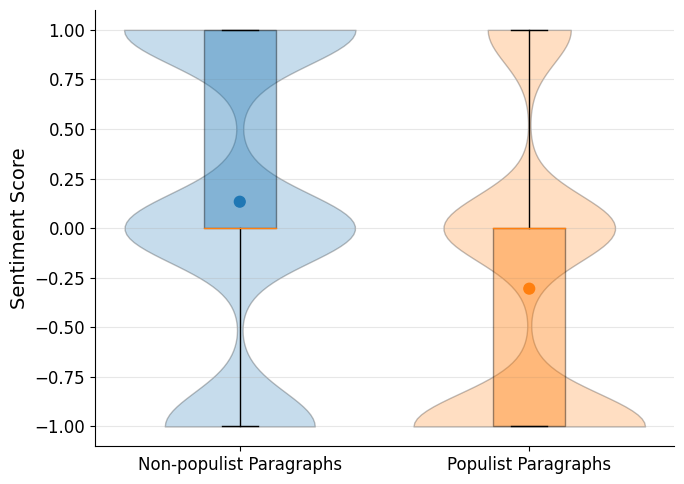

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


#  Violin + box + mean plot (Populism on X, formality on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "sentiment_label"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "sentiment_label"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("Sentiment Score")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Valence_Sentiment_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

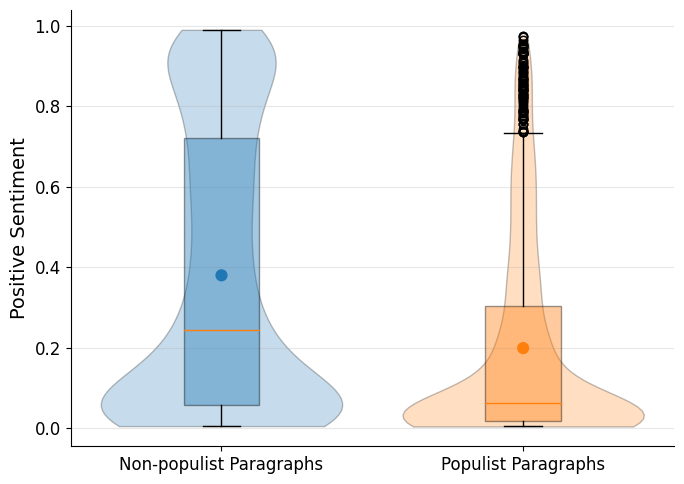

In [27]:
#  Violin + box + mean plot (Populism on X, formality on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "tw_pos"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "tw_pos"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("Positive Sentiment")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Positive_Sentiment_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

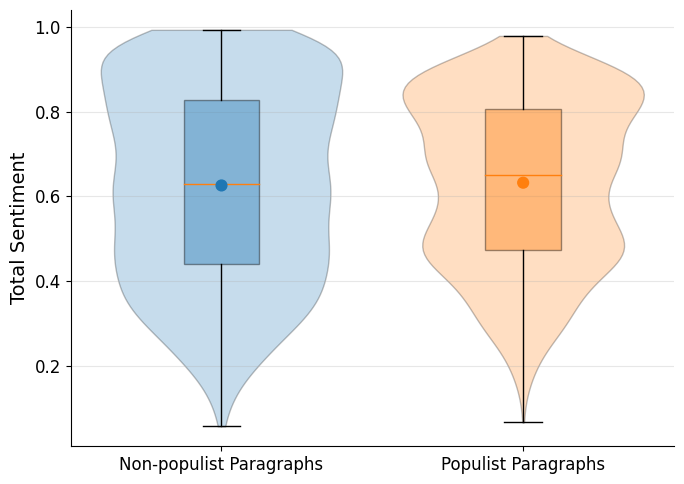

In [28]:
#  Violin + box + mean plot (Populism on X, formality on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "tw_intensity"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "tw_intensity"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("Total Sentiment")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Intensity_Sentiment_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
df_balanced.columns

Index(['Speech_id', 'text', 'party', 'term', 'comp', 'populist_old_keywords',
       'par_id', 'speech_par_id', 'Campaign', 'Authoritarianism', 'Exclusion',
       'Inclusion', 'High_pride', 'Low_pride', 'Populism', 'party_incumbent',
       'recession', 'prior_president', 'election_date', 'person', 'date',
       'name_date', 'weeks_to_election', 'cutoff_date', 'sent_pos', 'sent_neg',
       'sent_neu', 'sent_compound', 'sent_intensity', 'neg_per_100w',
       'pos_per_100w', 'election_year', 'tw_neg', 'tw_neu', 'tw_pos',
       'tw_label', 'tw_compound', 'tw_intensity', 'sentiment_label'],
      dtype='object')

In [30]:
most_negative_populist = df_balanced.loc[
    (df_balanced["Populism"] == 1) &
    (df_balanced["sent_neg"] == df_balanced.loc[df_balanced["Populism"] == 1, "sent_neg"].max())
]


In [31]:
most_negative_populist["text"].tolist()

["We're done with the chaos. The corruption. The failure. The irresponsibility. The indifference to American lives."]

In [35]:
snippets = {
    "high_positive_sentiment": "people from Dallas, from Texas, and those from Oklahoma",
    "high_negative_sentiment":  "In short, it's an economic proposal that does nothing to rebuild"
}

for label, snippet in snippets.items():
    match = df_balanced[df_balanced["text"].str.contains(snippet, regex=False, na=False)]
    print(f"\n{label}:")
    print(match[["person", "date"]].to_string())


high_positive_sentiment:
Empty DataFrame
Columns: [person, date]
Index: []

high_negative_sentiment:
          person        date
1105  Obama_2008  2008-10-21
